In [1]:
import os

SELECTED_DEVICE = f''
print(f'Setting CUDA visible devices to [{SELECTED_DEVICE}]')
os.environ['CUDA_VISIBLE_DEVICES'] = f'{SELECTED_DEVICE}'

Setting CUDA visible devices to []


In [ ]:
import jax
jax.config.update("jax_enable_x64", True) 

import jax.numpy as jnp
import pandas as pd

print('Jax version:          ', jax.__version__)
print('Jax default backend:  ', jax.default_backend())
print('Jax devices:          ', jax.devices())

Jax version:           0.4.35
Jax default backend:   cpu
Jax devices:           [CpuDevice(id=0)]


In [4]:
import matplotlib.pyplot as plt

SMALL_SIZE = 14
MEDIUM_SIZE = 16
LARGE_SIZE = 22

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=LARGE_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=LARGE_SIZE)  # fontsize of the figure title

A note on timing: Since SMC is adaptive, Jax has trouble running multiple chains in true parallel. While bamojax allows for multiple chains, these are actually performed sequentially (but within one chain, particles are processed in parallel). To determine the correct computation time per chain, a separate run was performed, and its running times have been imported here.

MH
MH, 500 (10): 40.90 SMC cycles, completed in 0.428 hrs (0.109 hrs per chain): -3808.248696536007
MH, 1000 (10): 41.40 SMC cycles, completed in 0.859 hrs (0.214 hrs per chain): -3805.393970181629
MH, 2000 (10): 40.80 SMC cycles, completed in 1.715 hrs (0.436 hrs per chain): -3804.988153814932
MH, 4000 (10): 41.30 SMC cycles, completed in 3.462 hrs (0.847 hrs per chain): -3802.6814740344557
MH, 8000 (10): 41.30 SMC cycles, completed in 6.836 hrs (1.691 hrs per chain): -3802.7485608391708
MH, 16000 (10): 41.20 SMC cycles, completed in 13.694 hrs (3.382 hrs per chain): -3801.46565864296
MH, 32000 (10): 41.20 SMC cycles, completed in 27.739 hrs (6.766 hrs per chain): -3800.844601131306
MH, 64000 (10): 40.90 SMC cycles, completed in 55.425 hrs (13.846 hrs per chain): -3800.9553529112077
Gibbs
Gibbs, 100 (10): 45.40 SMC cycles, completed in 0.282 hrs (0.076 hrs per chain): -3819.4378877996846
Gibbs, 200 (10): 46.20 SMC cycles, completed in 0.563 hrs (0.146 hrs per chain): -3815.43107161681

/tmp/ipykernel_3381539/413144594.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


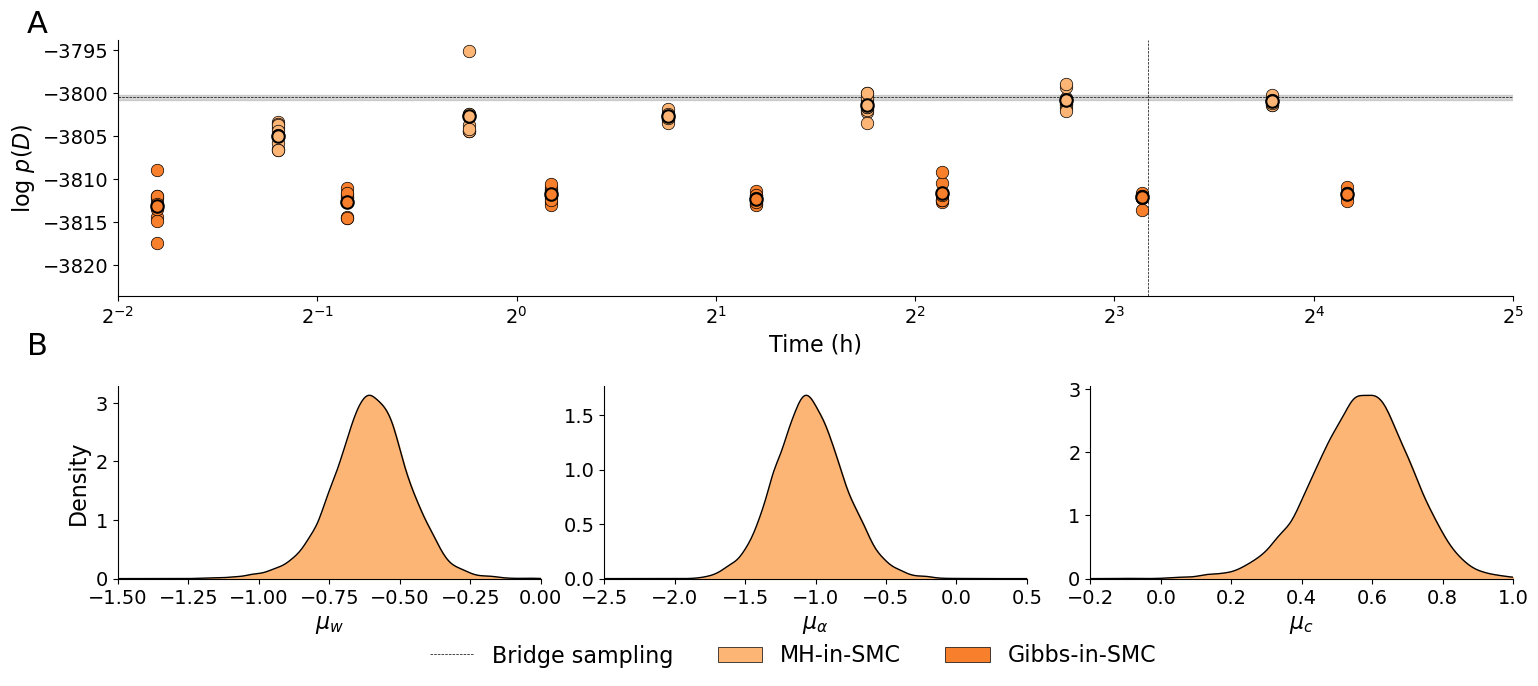

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from jax.scipy.stats import gaussian_kde

def plot_posterior(axes, kernel, seed, num_mcmc_steps, chain=None, color='w', alpha=1.0):
    if not isinstance(seed, list):
        seed = [seed]
    results = []
    for s in seed:
        filename = f'/home/maxhin/Documents/Code/SMC tutorial/Review1 results/hev/hev_lml_{kernel}_steps={num_mcmc_steps}_seed={s}_chains={num_chains}.npy'
        if not os.path.exists(filename):
            filename = f'/home/maxhin/Documents/Code/SMC tutorial/Review1 results/hev/hev_lml_{kernel}_particles={num_particles}_steps={num_mcmc_steps}_seed={s}_chains={num_chains}.npy'
            
        results.append(jnp.load(filename, allow_pickle=True).item()['final_state'].particles)

    particles = jax.tree_util.tree_map(lambda *x: jnp.vstack(x), *results)   
    limits = [[-1.5, 0.0], [-2.5, 0.5], [-0.2, 1]]
    names = [r'$\mu_w$', r'$\mu_\alpha$', r'$\mu_c$']
    res = 300

    pdfs = {}

    for ax, v, limit, name in zip(axes, ['w', 'a', 'c'], limits, names):
        if chain is None:
            samples = particles[f'mu_{v}'].flatten()
        else:
            samples = particles[f'mu_{v}'][chain, ...]
        pdf = gaussian_kde(samples)
        pdfs[f'mu_{v}'] = pdf
        input_range = jnp.linspace(*limit, num=res)        
        ax.fill_between(input_range, jnp.zeros_like(input_range), pdf(input_range), color=color, alpha=alpha)
        ax.plot(input_range, pdf(input_range), lw=1, color='k')
        ax.set_xlim(limit)
        ax.set_ylim(bottom=0)
        ax.set_xlabel(name, fontsize=MEDIUM_SIZE)
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

    for ax in axes:
        ax.tick_params('x', labelsize=SMALL_SIZE)
        ax.tick_params('y', labelsize=SMALL_SIZE)
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
    
    axes[0].set_ylabel('Density', fontsize=MEDIUM_SIZE);

    return pdfs

#
def get_timing(name, seed, num_mcmc_steps):
    filename = f'/home/maxhin/Documents/Code/SMC tutorial/Review1 results/hev/hev_lml_{name}_particles={num_particles}_steps={num_mcmc_steps}_seed={seed}_chains={1}.npy'
    if os.path.exists(filename):
        return jnp.load(filename, allow_pickle=True).item()['time']
    return jnp.inf

#

colors = plt.get_cmap('Oranges')([0.35, 0.55, 0.8])

# The experiment by Gronau et al. was performed 10 times to get an estimate of its variability
bs_lml = jnp.squeeze(jnp.asarray(pd.read_csv('/scratch/big/home/maxhin/Documents/Code/SMC tutorial/Bridge sampling/bs/collected_LML_10_runs.csv').values))

kernels = [dict(name='MH',
                seeds=[1234, 5678],
                steps=[500, 1000, 2000, 4000, 8000, 16000, 32000, 64000]), 
           dict(name='Gibbs',
                seeds=[2345, 7890],
                steps=[100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600])]

num_particles = 1000
num_chains = 5  # LML runs were done in 5 chains per attempt

lw = 0.5
ms = 9

fig = plt.figure(figsize=(18, 7))
gs = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[4/7, 3/7], hspace=0.4, wspace=0.15)

gs_lml = gs[0].subgridspec(1, 1)
gs_post = gs[1].subgridspec(1, 3)

ax_lml = fig.add_subplot(gs[0, :])
axes_post = [fig.add_subplot(gs[1, i]) for i in range(3)]

legend_handles = []

for i, kernel_settings in enumerate(kernels):
    name = kernel_settings['name']
    print(name)
    legend_handles.append(mpatches.Patch(facecolor=colors[i], label=f'{name}-in-SMC', edgecolor='k', linewidth=lw))

    seeds = kernel_settings['seeds']
    for num_mcmc_steps in kernel_settings['steps']:
        times = []
        lmls = []
        num_adapt_steps = []
        res = []
        for seed in seeds:
            filename = f'/home/maxhin/Documents/Code/SMC tutorial/Review1 results/hev/hev_lml_{name}_steps={num_mcmc_steps}_seed={seed}_chains={num_chains}.npy'
            if os.path.exists(filename):
                results = jnp.load(filename, allow_pickle=True).item()
                res.append(results['final_state'].particles)
                times.append(results['time'])
                lmls.append(results['lml'])
                num_adapt_steps.append(results['num_adapt'])
            else:
                filename = f'/home/maxhin/Documents/Code/SMC tutorial/Review1 results/hev/hev_lml_{name}_particles={num_particles}_steps={num_mcmc_steps}_seed={seed}_chains={num_chains}.npy'
                if os.path.exists(filename):
                    results = jnp.load(filename, allow_pickle=True).item()
                    res.append(results['final_state'].particles)
                    times.append(results['time'])
                    lmls.append(results['lml'])
                    num_adapt_steps.append(results['num_adapt'])

        particles = jax.tree_util.tree_map(lambda *x: jnp.vstack(x), *res)   
        
        time_in_hours = jnp.mean(jnp.asarray(times).flatten()) / 3600
        time_per_chain_in_hours = jnp.min(jnp.asarray([get_timing(name, seeds[0], num_mcmc_steps) / 3600, time_in_hours]))
        lml = jnp.asarray(lmls).flatten()              
        num_adapt = jnp.asarray(num_adapt_steps).flatten()

        m = len(lml)
        ax_lml.plot(time_per_chain_in_hours*jnp.ones((m, )), lml, 'o', color=colors[i], mec='k', mew=lw, alpha=1.0, ms=ms)
        ax_lml.plot(time_per_chain_in_hours, jnp.mean(lml), 'o', color=colors[i], mec='k', mew=3*lw, ms=ms)
        print(f'{name}, {num_mcmc_steps} ({m}): {jnp.mean(num_adapt):0.2f} SMC cycles, completed in {time_in_hours:0.3f} hrs ({time_per_chain_in_hours:0.3f} hrs per chain): {jnp.mean(lml)}')


ax_lml.set_xscale('log', base=2)

bs_time_in_hours = 9
mean_bs = jnp.mean(bs_lml)
std_bs = jnp.std(bs_lml)
ax_lml.axhspan(ymin=mean_bs - 2*std_bs, ymax=mean_bs + 2*std_bs, color='grey', alpha=0.3, zorder=-5)  # 95% of BS estimates
bs_runs = 10
obj = ax_lml.axhline(y=mean_bs, ls='--', lw=lw, color='k', label='Bridge sampling', zorder=-4)
ax_lml.axvline(x=bs_time_in_hours, ls='--', color='k', lw=lw, zorder=-4)
legend_handles.insert(0, obj)

ax_lml.set_xlabel('Time (h)', fontsize=MEDIUM_SIZE)
ax_lml.set_ylabel(r'log $p(D)$', fontsize=MEDIUM_SIZE)
ax_lml.set_xlim([1/2**2, 2**5])
ax_lml.tick_params(axis='x', labelsize=SMALL_SIZE)
ax_lml.tick_params(axis='y', labelsize=SMALL_SIZE)

for spine in ['top', 'right']:
    ax_lml.spines[spine].set_visible(False);

pdfs_mh = plot_posterior(axes_post, kernel='MH', seed=[1234, 5678], num_mcmc_steps=64000, color=colors[0])

plt.figtext(0.08, 0.89, 'A', size=LARGE_SIZE, ha='center', transform=plt.gcf().transFigure)
plt.figtext(0.08, 0.43, 'B', size=LARGE_SIZE, ha='center', transform=plt.gcf().transFigure)

plt.figlegend(handles=legend_handles, frameon=False, fontsize=MEDIUM_SIZE, ncol=3, bbox_to_anchor=(0.5, -0), loc='center')
plt.tight_layout()
plt.savefig(f'/scratch/big/home/maxhin/Documents/Code/SMC tutorial/Review1 results/hev_lml_MH_Gibbs.pdf', bbox_inches='tight', pad_inches=0.0)
plt.show()